# Cerința 3 — Metode ML cu Apache Spark MLlib

Aplicăm două metode de Machine Learning distincte folosind biblioteca **Spark MLlib** (`spark.ml`):

1. **Clasificare binară** — Predicția dacă o tentativă de șut va fi gol (`is_goal = 1/0`) folosind **Random Forest Classifier**
2. **Regresie** — Predicția numărului total de goluri dintr-un meci pe baza statisticilor agregate, folosind **Gradient-Boosted Trees (GBT) Regressor**

Pentru fiecare metodă: enunțul problemei, justificarea alegerii, aplicarea și evaluarea.

In [1]:
import os
# Notebook-urile stau în subfolderul notebooks/; ne asigurăm că lucrăm din rădăcina proiectului
# (unde se află data/, models/, plots/), astfel încât toate căile relative să funcționeze.
if not os.path.isdir('data') and os.path.isdir(os.path.join('..', 'data')):
    os.chdir('..')
# Directoarele de output trebuie să existe înainte de orice savefig()/save()
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)
print('Working directory:', os.getcwd())

Working directory: /Users/stefan/Documents/football-events-analysis


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum as spark_sum, avg, when, isnan
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    RegressionEvaluator
)
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 5)
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

spark = SparkSession.builder \
    .appName('FootballML') \
    .config('spark.driver.memory', '4g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('ERROR')
print('Spark version:', spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/11 20:06:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.2


## Pregătirea datelor comune

Citim datele, aplicăm filtrele de bază și pregătim dataset-urile pentru cele două probleme ML.

In [3]:
events_df = spark.read.csv('data/events.csv', header=True, inferSchema=True, nullValue='NA')
ginf_df   = spark.read.csv('data/ginf.csv',   header=True, inferSchema=True, nullValue='NA')

# Dataset șuturi curățat pentru Metoda 1
shots_df = events_df \
    .filter(
        (col('event_type') == 1) &
        col('is_goal').isNotNull() &
        col('location').isNotNull() &
        col('bodypart').isNotNull() &
        col('situation').isNotNull()
    ) \
    .fillna({'assist_method': 0, 'fast_break': 0, 'shot_place': 0, 'side': 1}) \
    .select('is_goal', 'location', 'bodypart', 'situation',
            'assist_method', 'fast_break', 'shot_place', 'side', 'time')

print(f'Șuturi: {shots_df.count():,} | Goluri: {shots_df.filter(col("is_goal")==1).count():,}')

Șuturi: 229,135 | Goluri: 24,441


---
## Metoda 1 — Clasificare binară: Predicția golurilor

### Enunțul problemei
**Întrebare:** Dat un șut cu caracteristicile sale (locație pe teren, parte a corpului folosită, situația de joc, tipul de assist, etc.), putem prezice dacă șutul va fi gol?

**Target:** `is_goal` ∈ {0, 1} — problemă de clasificare binară.

### Justificarea alegerii — Random Forest Classifier
- **Robust** la outlieri și valori lipsă
- Funcționează bine cu **date dezechilibrate** (~10% goluri vs 90% rateuri)
- Oferă **importanța variabilelor** — util pentru a înțelege ce caracteristici contează
- Nu necesită normalizare, se descurcă cu features categorice (după encoding)
- **Scalabil** distribuit în Spark MLlib

In [4]:
# Toate features sunt deja numerice (coduri întregi din dictionary.txt)
feature_cols_clf = ['location', 'bodypart', 'situation',
                    'assist_method', 'fast_break', 'shot_place', 'side', 'time']

# MLlib cere TOATE features într-o singură coloană de tip vector — VectorAssembler le concatenează.
# handleInvalid='skip': rândurile cu null/NaN rămase sunt eliminate (nu pot intra în vector).
assembler_clf = VectorAssembler(
    inputCols=feature_cols_clf,
    outputCol='features',
    handleInvalid='skip'
)

# Hiperparametrii Random Forest:
# - numTrees=100: mai mulți arbori = varianță mai mică a predicției (media votului e mai stabilă);
#   peste ~100 câștigul devine marginal iar costul crește liniar.
# - maxDepth=8: limitează adâncimea fiecărui arbore — arbori prea adânci memorează train-ul (overfit).
# - seed=42: reproducibilitate (bootstrap-ul și selecția de features sunt aleatorii).
rf = RandomForestClassifier(
    labelCol='is_goal',
    featuresCol='features',
    numTrees=100,
    maxDepth=8,
    seed=42
)

pipeline_clf = Pipeline(stages=[assembler_clf, rf])

# Split 80/20 stratificat
train_clf, test_clf = shots_df.randomSplit([0.8, 0.2], seed=42)
print(f'Train: {train_clf.count():,} | Test: {test_clf.count():,}')

Train: 183,555 | Test: 45,580


### Antrenarea modelului

`pipeline_clf.fit(train_clf)` antrenează cei 100 de arbori pe datele de train și întoarce un `PipelineModel` (toate etapele devenite transformeri). `transform(test_clf)` adaugă coloanele `prediction` (clasa prezisă) și `probability` (vectorul de probabilități per clasă).

**De reținut:** `fit()` e momentul în care Spark execută efectiv job-ul distribuit — fiecare arbore se antrenează pe un eșantion bootstrap, iar la fiecare split se consideră doar un subset aleator de features (asta diferențiază Random Forest de simple bagged trees).

In [5]:
print('Antrenare Random Forest...')
model_clf = pipeline_clf.fit(train_clf)
predictions_clf = model_clf.transform(test_clf)
print('Antrenare completă.')
predictions_clf.select('is_goal', 'prediction', 'probability').show(5)

Antrenare Random Forest...


Antrenare completă.


+-------+----------+--------------------+
|is_goal|prediction|         probability|
+-------+----------+--------------------+
|      0|       0.0|[0.95398155380278...|
|      0|       0.0|[0.95406178025158...|
|      0|       0.0|[0.95406178025158...|
|      0|       0.0|[0.95398155380278...|
|      0|       0.0|[0.95398155380278...|
+-------+----------+--------------------+
only showing top 5 rows


### Evaluarea clasificatorului — mai multe metrici, nu doar Accuracy

Pe date dezechilibrate (~10% goluri) accuracy singură e înșelătoare: un model care prezice mereu „nu e gol" ar avea ~90% accuracy fiind inutil. De aceea raportăm AUC-ROC (calitatea ordonării probabilităților, independentă de prag), F1, Precision și Recall (weighted).

**De reținut:** AUC = probabilitatea ca modelul să dea scor mai mare unui gol real decât unui ne-gol ales aleator; 0.5 = aleator, 1.0 = perfect.

In [6]:
# Evaluare clasificare
bin_eval = BinaryClassificationEvaluator(labelCol='is_goal', metricName='areaUnderROC')
mc_eval_acc = MulticlassClassificationEvaluator(labelCol='is_goal', metricName='accuracy')
mc_eval_f1  = MulticlassClassificationEvaluator(labelCol='is_goal', metricName='f1')
mc_eval_prec = MulticlassClassificationEvaluator(labelCol='is_goal', metricName='weightedPrecision')
mc_eval_rec  = MulticlassClassificationEvaluator(labelCol='is_goal', metricName='weightedRecall')

auc      = bin_eval.evaluate(predictions_clf)
accuracy = mc_eval_acc.evaluate(predictions_clf)
f1       = mc_eval_f1.evaluate(predictions_clf)
prec     = mc_eval_prec.evaluate(predictions_clf)
rec      = mc_eval_rec.evaluate(predictions_clf)

print('=== Metrici Clasificare — Random Forest ===')
print(f'  AUC-ROC          : {auc:.4f}')
print(f'  Accuracy         : {accuracy:.4f}')
print(f'  F1-Score (wgt)   : {f1:.4f}')
print(f'  Precision (wgt)  : {prec:.4f}')
print(f'  Recall (wgt)     : {rec:.4f}')

=== Metrici Clasificare — Random Forest ===
  AUC-ROC          : 0.9545
  Accuracy         : 0.9298
  F1-Score (wgt)   : 0.9159
  Precision (wgt)  : 0.9304
  Recall (wgt)     : 0.9298


### Importanța variabilelor

Extragem `featureImportances` din modelul RF: cât a contribuit fiecare feature la reducerea totală a impurității (Gini), mediat peste toți arborii. Ne arată *pe ce se bazează* modelul când prezice golul.

**De reținut:** ne așteptăm ca `location` și `shot_place` să domine — poziția șutului e cel mai informativ predictor al golului, în acord cu intuiția fotbalistică.

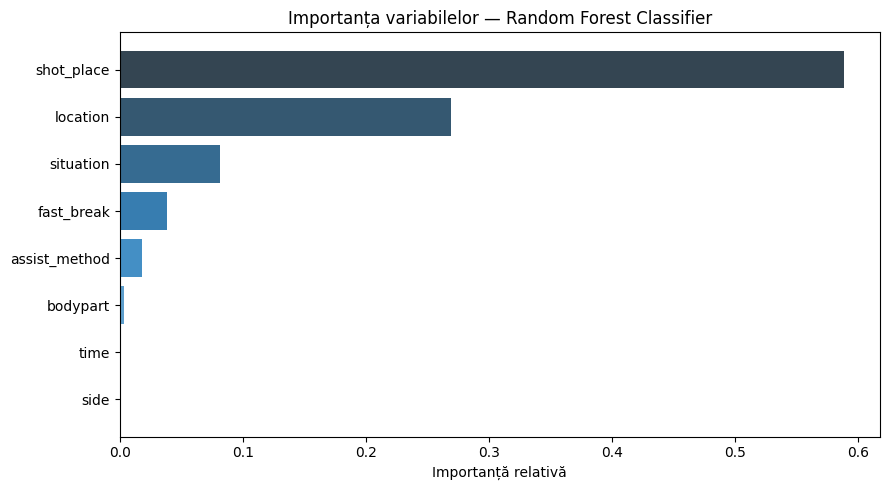


Top features:
  shot_place          : 0.5882
  location            : 0.2688
  situation           : 0.0818
  fast_break          : 0.0381
  assist_method       : 0.0180
  bodypart            : 0.0036
  time                : 0.0013
  side                : 0.0002


In [7]:
# Importanța variabilelor
rf_model = model_clf.stages[-1]
importances = rf_model.featureImportances.toArray()

feat_imp = sorted(zip(feature_cols_clf, importances), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(9, 5))
names, values = zip(*feat_imp)
ax.barh(names[::-1], values[::-1], color=sns.color_palette('Blues_d', len(names)))
ax.set_title('Importanța variabilelor — Random Forest Classifier')
ax.set_xlabel('Importanță relativă')
plt.tight_layout()
plt.savefig('plots/fig_feature_importance_clf.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop features:')
for name, val in feat_imp:
    print(f'  {name:<20}: {val:.4f}')

### Matricea de confuzie

Numărăm combinațiile (clasă reală × clasă prezisă) cu un `groupBy` distribuit și pivotăm rezultatul în pandas pentru vizualizare. Matricea descompune erorile în False Positives (șuturi prezise gol care nu au fost) și False Negatives (goluri ratate de model).

**De reținut:** pe date dezechilibrate, FN-urile (goluri nedetectate) sunt de obicei problema principală — modelul „preferă" clasa majoritară; exact asta corectăm mai jos cu `weightCol`.

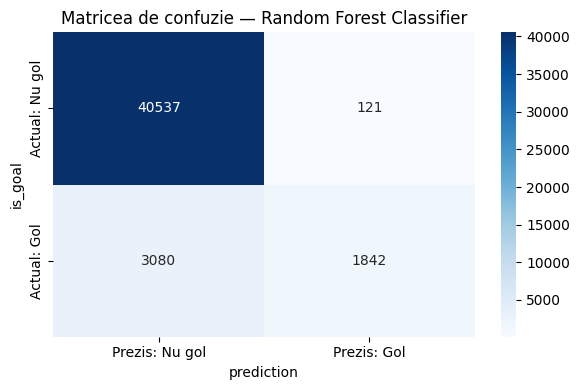

In [8]:
# Matricea de confuzie
cm_data = predictions_clf \
    .groupBy('is_goal', 'prediction') \
    .count() \
    .orderBy('is_goal', 'prediction') \
    .toPandas()

cm_pivot = cm_data.pivot(index='is_goal', columns='prediction', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_pivot, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=['Prezis: Nu gol', 'Prezis: Gol'],
            yticklabels=['Actual: Nu gol', 'Actual: Gol'], ax=ax)
ax.set_title('Matricea de confuzie — Random Forest Classifier')
plt.tight_layout()
plt.savefig('plots/fig_confusion_matrix_clf.png', dpi=120, bbox_inches='tight')
plt.show()

### Diagnoză: overfitting (AUC train vs test)

**Ce verificăm:** Evaluăm același Random Forest pe setul de *train* și pe cel de *test*, comparând AUC-ROC. Dacă modelul memorează datele de antrenament în loc să învețe tipare generalizabile, AUC pe train va fi semnificativ mai mare decât pe test.

**De ce contează:** Un model care merge perfect pe train dar slab pe test e inutil în producție. Analogie backend: e ca un cache care dă hit doar pentru request-urile pe care le-a văzut deja — ce ne interesează e generalizarea (gap mic train-test). Regulă practică: gap < 0.02 = sănătos, 0.02–0.05 = ușor, > 0.05 = overfitting de tratat (reducere `maxDepth`, mai multe date, regularizare).

=== Diagnoză overfitting — Random Forest (baseline) ===
  AUC train : 0.9549
  AUC test  : 0.9545
  Gap       : 0.0005
  Verdict   : NU overfit — generalizează bine (gap < 0.02)


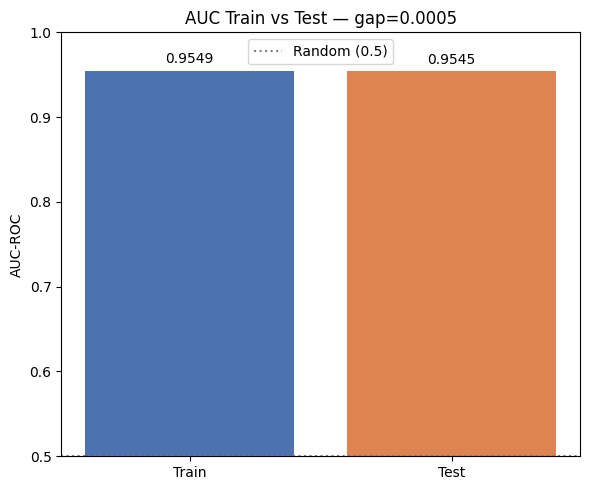

In [9]:
# Verificare overfitting: comparăm AUC-ROC pe train vs test pentru Random Forest baseline
preds_train_clf = model_clf.transform(train_clf)
auc_train = bin_eval.evaluate(preds_train_clf)
auc_test  = bin_eval.evaluate(predictions_clf)   # același set test ca mai sus
gap = auc_train - auc_test

print('=== Diagnoză overfitting — Random Forest (baseline) ===')
print(f'  AUC train : {auc_train:.4f}')
print(f'  AUC test  : {auc_test:.4f}')
print(f'  Gap       : {gap:.4f}')
if gap < 0.02:
    verdict = 'NU overfit — generalizează bine (gap < 0.02)'
elif gap < 0.05:
    verdict = 'Overfitting UȘOR — acceptabil (gap 0.02-0.05)'
else:
    verdict = 'Overfitting SEMNIFICATIV — reduceți maxDepth / mai multe date'
print(f'  Verdict   : {verdict}')

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Train', 'Test'], [auc_train, auc_test], color=['#4c72b0', '#dd8452'])
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.axhline(0.5, color='gray', linestyle=':', label='Random (0.5)')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('AUC-ROC')
ax.set_title(f'AUC Train vs Test — gap={gap:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('plots/fig_auc_train_vs_test.png', dpi=120, bbox_inches='tight')
plt.show()

### Tratarea dezechilibrului de clase (`weightCol`)

**Problema:** Doar ~10-12% din șuturi sunt goluri. Un model antrenat naiv învață să prezică „nu e gol" aproape mereu — obține accuracy mare, dar **recall slab pe goluri** (ratează exact clasa care ne interesează).

**Soluția:** Asignăm fiecărui exemplu o pondere invers proporțională cu frecvența clasei sale (*balanced weighting*): golurile (clasa minoritară) primesc pondere mai mare, forțând modelul să le ia în serios. `RandomForestClassifier` din Spark MLlib acceptă direct un parametru `weightCol`. Comparăm recall-ul pe goluri și matricea de confuzie față de modelul baseline — de obicei recall-ul pe minoritate **crește**, cu un mic compromis pe accuracy/precision (un trade-off conștient).

Distribuție train: goluri=19,519 (10.6%) | ne-goluri=164,036
Pondere gol=0.894 | pondere ne-gol=0.106 (raport 8.4x)

Antrenare Random Forest cu ponderi pe clase...



=== Baseline vs Ponderat (clasa minoritară = goluri) ===
  Recall goluri baseline : 0.3742
  Recall goluri ponderat : 0.9415
  AUC baseline / ponderat: 0.9545 / 0.9587
  Accuracy ponderat      : 0.8509


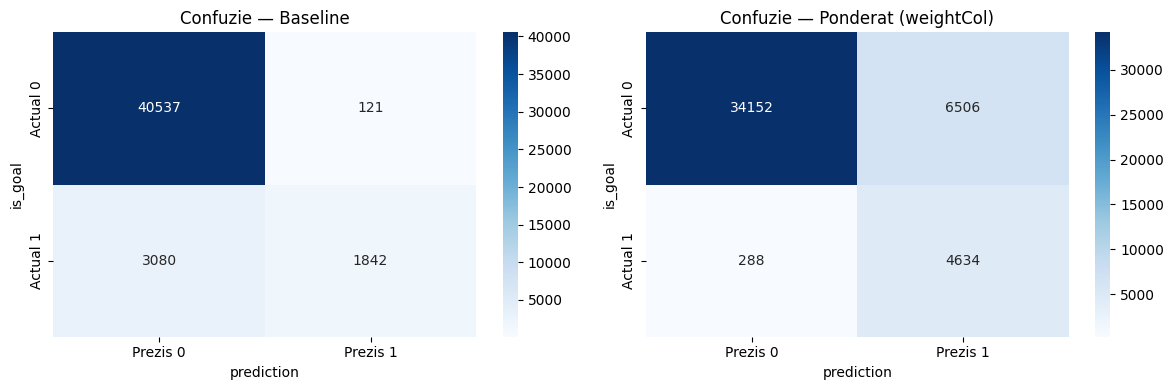

In [10]:
from pyspark.sql.functions import lit

# Ponderi din distribuția claselor pe train (balanced weighting):
# fiecare clasă primește o pondere = fracția clasei OPUSE => minoritarul (goluri) cântărește mai mult
n_total = train_clf.count()
n_pos   = train_clf.filter(col('is_goal') == 1).count()
n_neg   = n_total - n_pos
w_pos   = n_neg / n_total
w_neg   = n_pos / n_total
print(f'Distribuție train: goluri={n_pos:,} ({n_pos/n_total*100:.1f}%) | ne-goluri={n_neg:,}')
print(f'Pondere gol={w_pos:.3f} | pondere ne-gol={w_neg:.3f} (raport {w_pos/w_neg:.1f}x)')

train_w = train_clf.withColumn(
    'classWeight',
    when(col('is_goal') == 1, lit(w_pos)).otherwise(lit(w_neg))
)

rf_weighted = RandomForestClassifier(
    labelCol='is_goal', featuresCol='features', weightCol='classWeight',
    numTrees=100, maxDepth=8, seed=42
)
pipeline_clf_w = Pipeline(stages=[assembler_clf, rf_weighted])

print('\nAntrenare Random Forest cu ponderi pe clase...')
model_clf_w = pipeline_clf_w.fit(train_w)
preds_w = model_clf_w.transform(test_clf)


def confusion_2x2(preds):
    """Matrice de confuzie 2x2 robustă (reindexare ca să existe mereu ambele clase)."""
    cm = preds.groupBy('is_goal', 'prediction').count().toPandas()
    return (cm.pivot(index='is_goal', columns='prediction', values='count')
              .reindex(index=[0, 1], columns=[0.0, 1.0]).fillna(0))


def recall_goluri(cmp):
    tp, fn = cmp.loc[1, 1.0], cmp.loc[1, 0.0]
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


cm_base = confusion_2x2(predictions_clf)
cm_w    = confusion_2x2(preds_w)
auc_w   = bin_eval.evaluate(preds_w)
acc_w   = mc_eval_acc.evaluate(preds_w)

print('\n=== Baseline vs Ponderat (clasa minoritară = goluri) ===')
print(f'  Recall goluri baseline : {recall_goluri(cm_base):.4f}')
print(f'  Recall goluri ponderat : {recall_goluri(cm_w):.4f}')
print(f'  AUC baseline / ponderat: {auc_test:.4f} / {auc_w:.4f}')
print(f'  Accuracy ponderat      : {acc_w:.4f}')

# Matrice de confuzie comparativă baseline vs ponderat
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cmp, titlu in [(axes[0], cm_base, 'Baseline'),
                       (axes[1], cm_w, 'Ponderat (weightCol)')]:
    sns.heatmap(cmp, annot=True, fmt='.0f', cmap='Blues', ax=ax,
                xticklabels=['Prezis 0', 'Prezis 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    ax.set_title(f'Confuzie — {titlu}')
plt.tight_layout()
plt.savefig('plots/fig_confusion_weighted_vs_baseline.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Metoda 2 — Regresie: Predicția numărului de goluri pe meci

### Enunțul problemei
**Întrebare:** Pe baza statisticilor agregate dintr-un meci (număr de corneruri, fault-uri, șuturi, cartonașe per echipă), putem prezice **câte goluri** se vor marca în total?

**Target:** `total_goals` = `fthg + ftag` — variabilă continuă ≥ 0 → **problemă de regresie**.

### Justificarea alegerii — GBT Regressor
- **Gradient-Boosted Trees** sunt robuste și performante pe date tabulare
- Capturează **relații non-liniare** complexe (ex: un meci cu 20 corneruri nu înseamnă neapărat mai multe goluri)
- Minimizează iterativ eroarea pe exemple dificile (**boosting**)
- Diferit metodologic față de Random Forest (bagging vs boosting) — demonstrăm diversitate de abordări

In [11]:
from pyspark.sql.functions import countDistinct

# Agregăm statistici per meci din events_df.
# Pattern-ul count(when(cond, 1)) = "COUNT cu filtru" (echivalentul SQL COUNT(CASE WHEN...)):
# when() întoarce 1 unde condiția e adevărată și null altfel, iar count() numără doar non-null.
# Astfel numărăm mai multe tipuri de evenimente într-o SINGURĂ trecere peste date (un singur shuffle).
match_stats = events_df.groupBy('id_odsp').agg(
    count(when(col('event_type') == 1, 1)).alias('total_suturi'),
    count(when((col('event_type') == 1) & (col('side') == 1), 1)).alias('suturi_acasa'),
    count(when((col('event_type') == 1) & (col('side') == 2), 1)).alias('suturi_deplasare'),
    count(when(col('event_type') == 2, 1)).alias('corneruri'),
    count(when(col('event_type') == 3, 1)).alias('falturi'),
    count(when(col('event_type') == 4, 1)).alias('galbene'),
    count(when(col('event_type') == 6, 1)).alias('rosii'),
    count(when(col('event_type') == 11, 1)).alias('penaltiuri'),
    count(when(col('fast_break') == 1, 1)).alias('contraatacuri')
)

# Join cu ginf pentru target (total goluri)
reg_df = match_stats.join(
    ginf_df.select('id_odsp', 'fthg', 'ftag'),
    on='id_odsp', how='inner'
).withColumn(
    'total_goals',
    (col('fthg') + col('ftag')).cast('double')
).drop('id_odsp', 'fthg', 'ftag') \
 .filter(col('total_goals').isNotNull())

print(f'Meciuri pentru regresie: {reg_df.count():,}')
reg_df.describe('total_goals', 'total_suturi', 'corneruri').show()

Meciuri pentru regresie: 9,074


+-------+------------------+------------------+------------------+
|summary|       total_goals|      total_suturi|         corneruri|
+-------+------------------+------------------+------------------+
|  count|              9074|              9074|              9074|
|   mean| 2.695724046726912|25.251818382190876|10.051135111307032|
| stddev|1.6819427293998597|5.7523718865185085|3.4086506561293533|
|    min|               0.0|                 5|                 1|
|    max|              12.0|                51|                26|
+-------+------------------+------------------+------------------+



### Asamblarea features și configurarea GBT

`VectorAssembler` împachetează cele 9 statistici agregate per meci într-o singură coloană `features` (formatul obligatoriu MLlib), apoi `GBTRegressor` antrenează 50 de arbori *secvențial* — fiecare arbore nou corectează reziduurile celor anteriori, ponderat cu `stepSize=0.1` (learning rate).

**De reținut:** diferența fundamentală față de Random Forest — RF antrenează arbori independenți în paralel (bagging, reduce varianța), GBT îi antrenează în lanț (boosting, reduce bias-ul).

In [12]:
feature_cols_reg = ['total_suturi', 'suturi_acasa', 'suturi_deplasare',
                    'corneruri', 'falturi', 'galbene', 'rosii',
                    'penaltiuri', 'contraatacuri']

assembler_reg = VectorAssembler(
    inputCols=feature_cols_reg,
    outputCol='features',
    handleInvalid='skip'
)

# Hiperparametrii GBT (boosting):
# - maxIter=50: numărul de arbori construiți SECVENȚIAL — fiecare corectează reziduurile precedentului.
# - maxDepth=5: arbori mai mici decât la RF; în boosting, mulți "învățăcei slabi" > puțini arbori adânci.
# - stepSize=0.1 (learning rate): cât din corecția fiecărui arbore se aplică — valori mici învață
#   mai lent dar generalizează mai bine (același rol ca learning rate-ul la rețele neuronale).
gbt = GBTRegressor(
    labelCol='total_goals',
    featuresCol='features',
    maxIter=50,
    maxDepth=5,
    stepSize=0.1,
    seed=42
)

pipeline_reg = Pipeline(stages=[assembler_reg, gbt])

train_reg, test_reg = reg_df.randomSplit([0.8, 0.2], seed=42)
print(f'Train: {train_reg.count():,} | Test: {test_reg.count():,}')

print('Antrenare GBT Regressor...')
model_reg = pipeline_reg.fit(train_reg)
preds_reg  = model_reg.transform(test_reg)
print('Antrenare completă.')

Train: 7,333 | Test: 1,741
Antrenare GBT Regressor...


Antrenare completă.


### Evaluarea regresiei — RMSE, MAE, R²

RMSE penalizează pătratic erorile mari, MAE e eroarea medie „în goluri" (direct interpretabilă), iar R² spune ce proporție din varianța numărului de goluri e explicată de model.

**De reținut:** un R² modest e așteptat aici — numărul de goluri dintr-un meci e intrinsec stocastic; statisticile de joc (șuturi, corneruri) corelează cu golurile, dar nu le determină.

In [13]:
rmse_eval = RegressionEvaluator(labelCol='total_goals', metricName='rmse')
mae_eval  = RegressionEvaluator(labelCol='total_goals', metricName='mae')
r2_eval   = RegressionEvaluator(labelCol='total_goals', metricName='r2')

rmse = rmse_eval.evaluate(preds_reg)
mae  = mae_eval.evaluate(preds_reg)
r2   = r2_eval.evaluate(preds_reg)

print('=== Metrici Regresie — GBT Regressor ===')
print(f'  RMSE  : {rmse:.4f}  (eroare medie pătratică)')
print(f'  MAE   : {mae:.4f}  (eroare medie absolută)')
print(f'  R²    : {r2:.4f}  (proporția varianței explicate)')

=== Metrici Regresie — GBT Regressor ===
  RMSE  : 1.5828  (eroare medie pătratică)
  MAE   : 1.2618  (eroare medie absolută)
  R²    : 0.0717  (proporția varianței explicate)


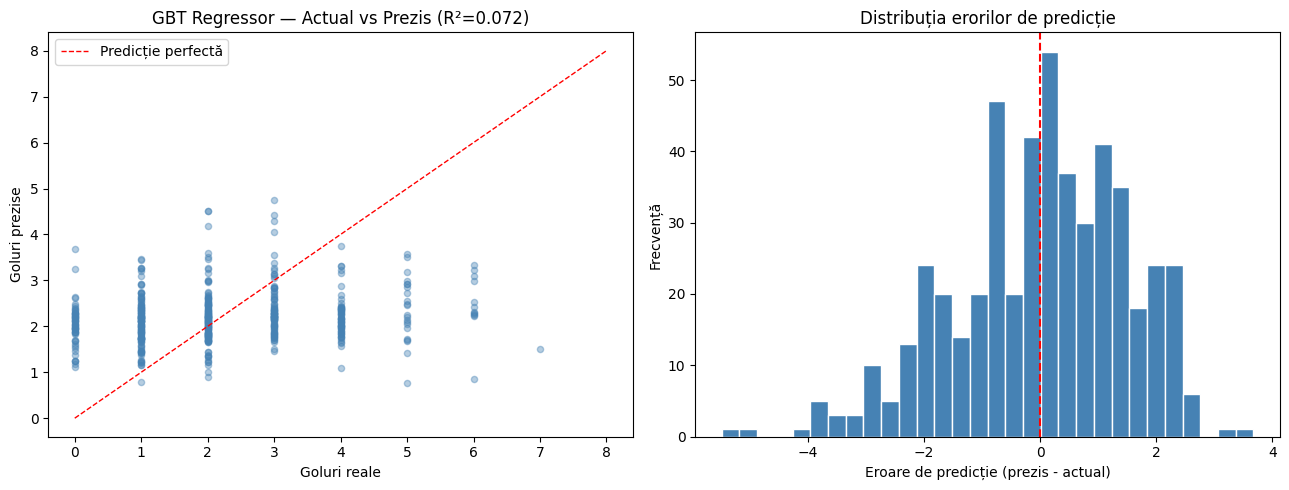

Sesiune Spark oprită.


In [14]:
# Vizualizare: valori reale vs prezise
sample_preds = preds_reg.select('total_goals', 'prediction').limit(500).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter actual vs predicted
axes[0].scatter(sample_preds['total_goals'], sample_preds['prediction'],
                alpha=0.4, color='steelblue', s=20)
lims = [0, max(sample_preds['total_goals'].max(), sample_preds['prediction'].max()) + 1]
axes[0].plot(lims, lims, 'r--', lw=1, label='Predicție perfectă')
axes[0].set_xlabel('Goluri reale')
axes[0].set_ylabel('Goluri prezise')
axes[0].set_title(f'GBT Regressor — Actual vs Prezis (R²={r2:.3f})')
axes[0].legend()

# Distribuția erorilor
errors = sample_preds['prediction'] - sample_preds['total_goals']
axes[1].hist(errors, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Eroare de predicție (prezis - actual)')
axes[1].set_ylabel('Frecvență')
axes[1].set_title('Distribuția erorilor de predicție')

plt.tight_layout()
plt.savefig('plots/fig_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

spark.stop()
print('Sesiune Spark oprită.')